In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

import textwrap
from matplotlib.patches import Patch

### Export NMF results and metadata 

In [41]:
k = 7
data_type = 'functions'

results_path = f"../results/{data_type}/random_split/nmf_trained/nsig_{k}"

In [42]:
W_path = f'{results_path}/best_run/W_{k}.csv'
H_train_path = f'{results_path}/best_run/H_train_{k}.csv'
H_test_path = f'{results_path}/best_run/H_test_{k}.csv'

W = pd.read_csv(W_path, index_col=0)
H_train = pd.read_csv(H_train_path, index_col=0)
H_test = pd.read_csv(H_test_path, index_col=0)

W.columns = [i for i in range(1, k + 1)]
H_train.index = [i for i in range(1, k + 1)]
H_test.index = [i for i in range(1, k + 1)]

metadata = pd.read_csv("../data/metadata.tsv", sep="\t", index_col=None)
pathways = pd.read_csv("../data/pathways_metadata.tsv", sep="\t", index_col=0)

In [43]:
# By normalizing the H matrix column-wise, we obtained the relative abundance of ES in each sample. We define as primary ES the ES of a sample with the highest relative abundance.
H_train_norm = H_train.div(H_train.sum(axis=0), axis=1) * 100
H_test_norm = H_test.div(H_test.sum(axis=0), axis=1) * 100

# Normalizing W by its its rows or columns informs on the general composition of ESs in genera, and on the association strength of genera to each ES, respectively

W_norm_row  = W.div(W.sum(axis=1), axis=0) * 100 # Informs on the general composition of ESs in genera
W_norm_col  = W.div(W.sum(axis=0), axis=1) * 100 # Find association strength of genera to each ES
H_train_norm.shape, W_norm_col.shape

((7, 12273), (623, 7))

In [44]:
# Reset index to make it a column
W_norm_col_annot = W_norm_col.reset_index()
pathways = pathways.reset_index()

# Merge
W_norm_col_annot = W_norm_col_annot.merge(pathways, on='index', how='left')

# Set index back to the original
W_norm_col_annot = W_norm_col_annot.set_index('index')

In [7]:
# Reset index to make it a rowumn
W_norm_row_annot = W_norm_row.reset_index()
pathways = pathways.reset_index()

# Merge
W_norm_row_annot = W_norm_row_annot.merge(pathways, on='index', how='left')

# Set index back to the original
W_norm_row_annot = W_norm_row_annot.set_index('index')

### Visualise pathway distribution for each funct ESs

In [ ]:
def show_top_pathways(df, n_top_features=5, metacyc_group='pathway', n_cols=4, n_rows=2):
    df = df.copy()
    # Identify topic columns
    metadata_cols = ['Superclass1', 'Superclass2', 'pathway']
    topic_cols = [col for col in df.columns if col not in metadata_cols]
    
    # Prepare labels - use y_label_col directly even if duplicates
    if metacyc_group in df.columns:
        label_series = df[metacyc_group].astype(str)
        unique_labels = df.index.astype(str) + '_' + label_series # Use original index for uniqueness in the background
    else:
        raise ValueError(f'no metacyc group {metacyc_group}.')
    
    # Prepare data with labels
    df['unique_label'] = unique_labels
    df = df.set_index('unique_label')
    
    # values from 'metacyc_group' are for display
    display_label_map = df[metacyc_group].to_dict()
    
    # Get top features for each ES
    top_features_dict = {} # this will be output
    top_features_df = pd.DataFrame()
    
    for topic in topic_cols:
        # Sort and get top features
        top_for_topic = df[topic].sort_values(ascending=False).head(n_top_features)
        top_features_dict[topic] = top_for_topic # for output
        top_features_df = pd.concat([top_features_df, top_for_topic], axis=1)
    
    top_features_df.columns = [f'Topic_{i+1}' for i in range(len(topic_cols))]
    
    #################################################################################
    # PLOT

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 20))
    
    # Handle axes
    if n_rows == 1 and n_cols == 1:
        axes = np.array([axes])
    else:
        axes = axes.flatten()
    
    # Color scale
    all_values = top_features_df.fillna(0).values.flatten()
    vmin, vmax = all_values.min(), all_values.max()
    
    # Create heatmaps per each ES
    for i, topic in enumerate(topic_cols):
        if i >= len(axes):
            break
            
        topic_data = top_features_dict[topic].to_frame()
        
        # ANNOTATIONS
        display_labels = []
        for j in topic_data.index:
            if j in display_label_map:
                display_labels.append(str(display_label_map[j]))
            else:
                display_labels.append(str(j))
        
        annot_matrix = topic_data.copy()
        annot_values = []
        max_chars = 15 # Max chars per line

        for name, val in zip(display_labels, topic_data.iloc[:, 0]):
            if len(name) > max_chars: # Wrap text if needed
                wrapped = '\n'.join(textwrap.wrap(name, width=max_chars))
            else:
                wrapped = name
            
            # Format value
            val_str = f"{val:.3f}" if metacyc_group == 'pathway' else ''
            annot_values.append(f"{wrapped}\n{val_str}")
        
        annot_matrix.iloc[:, 0] = annot_values
        
        # Heatmap
        fontsize = 9
        heatmap = sns.heatmap(topic_data,
                            cmap='Blues',
                            annot=annot_matrix,
                            fmt='',
                            annot_kws={
                                'weight': 'bold',
                                'size': fontsize,
                                'ha': 'center',
                                'va': 'center',
                                'linespacing': 1.0
                            },
                            cbar=(i == len(topic_cols) - 1),
                            cbar_kws={
                                'label': 'Contribution Strength',
                                'shrink': 0.8
                            } if i == len(topic_cols) - 1 else {},
                            vmin=vmin,
                            vmax=vmax,
                            ax=axes[i],
                            xticklabels=[],
                            yticklabels=False,
                            square=False,
                            linewidths=0.5,
                            linecolor='white')
        
        axes[i].set_title(f'{topic}', fontsize=14, fontweight='bold', pad=10)
        axes[i].set_ylabel('')
        axes[i].set_yticks([])
        
        if i == len(topic_cols) - 1:
            cbar = heatmap.collections[0].colorbar
            if cbar is not None:
                cbar.ax.tick_params(labelsize=10)
                cbar.set_label('Contribution strength (%)', fontsize=12)
    
    # Turn off unused axes
    for j in range(len(topic_cols), len(axes)):
        axes[j].axis('off')
    
    plt.tight_layout()
    #plt.savefig('../images/Superclass2.png', dpi=200)
    plt.show()
    plt.close()
    
    return top_features_dict

/tmp/ipykernel_17597/813482909.py:77: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['Nucleoside and\nNucleotide\nBiosynthesis\n', 'Aminoacyl-tRNA\nCharging\n', 'Nucleoside and\nNucleotide\nBiosynthesis\n', 'Cell Structure\nBiosynthesis\n', 'Cell Structure\nBiosynthesis\n', 'Nucleoside and\nNucleotide\nBiosynthesis\n', 'Cell Structure\nBiosynthesis\n', 'Nucleoside and\nNucleotide\nBiosynthesis\n', 'Cell Structure\nBiosynthesis\n', 'Carbohydrate De\ngradation&&Poly\nmeric Compound\nDegradation\n', 'Glycolysis\n', 'Cofactor,\nCarrier, and\nVitamin\nBiosynthesis\n', 'Nucleic Acid\nProcessing\n', 'Amino Acid\nBiosynthesis\n', 'Amino Acid\nBiosynthesis\n', 'Fermentation\n', 'Cofactor,\nCarrier, and\nVitamin\nBiosynthesis\n', 'Cofactor,\nCarrier, and\nVitamin\nBiosynthesis\n', 'Nucleoside and\nNucleotide\nBiosynthesis\n', 'Nucleoside and\nNucleotide\nBiosynthesis\n']' has dtype incompatible with float64, please explicitl

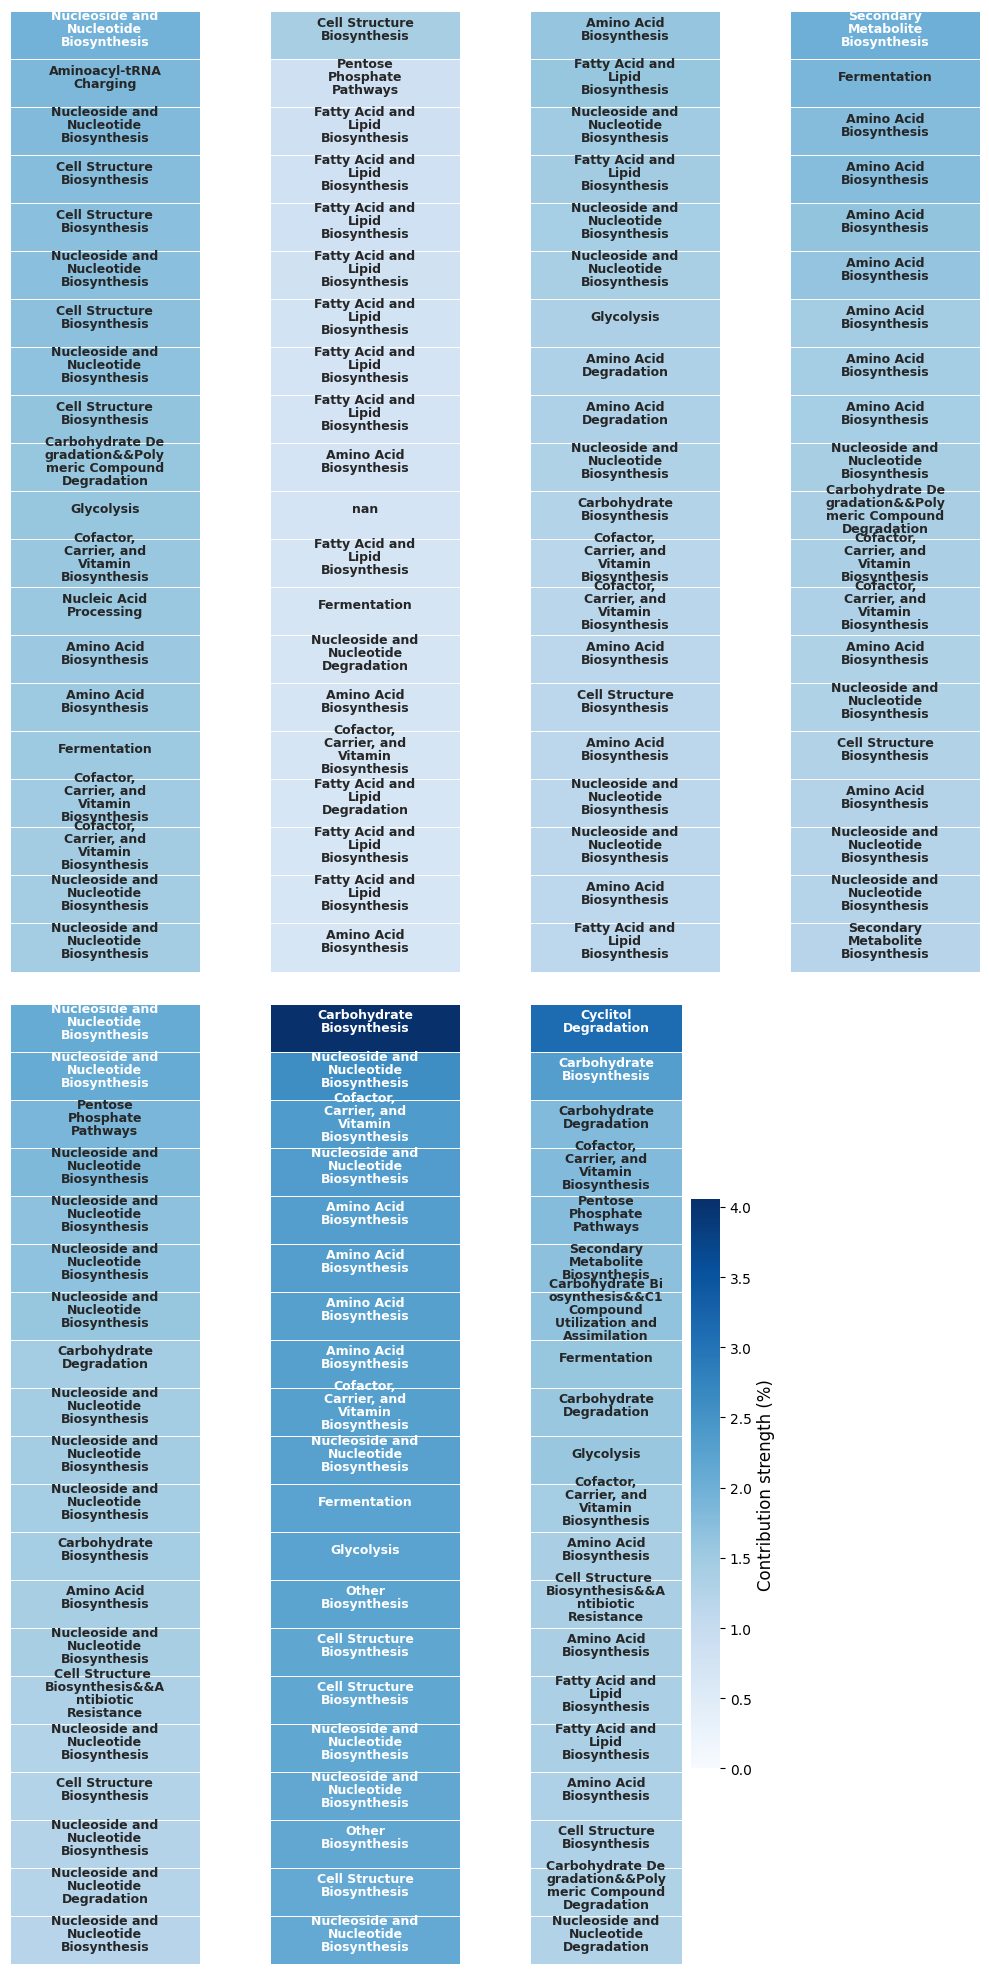

In [53]:
top_functions_superclass2 = show_top_pathways(df=W_norm_col_annot, n_top_features=20, metacyc_group='Superclass2')

/tmp/ipykernel_17597/813482909.py:77: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['adenosine\nribonucleotides\nde novo\nbiosynthesis\n1.963', 'tRNA charging\n1.852', 'UMP\nbiosynthesis I\n1.819', 'UDP-N-\nacetylmuramoyl-\npentapeptide\nbiosynthesis II\n(lysine-\ncontaining)\n1.744', 'UDP-N-\nacetylmuramoyl-\npentapeptide\nbiosynthesis I\n(meso-\ndiaminopimelate\ncontaining)\n1.722', 'adenine and\nadenosine\nsalvage III\n1.712', 'peptidoglycan\nbiosynthesis I\n(meso-\ndiaminopimelate\ncontaining)\n1.699', 'guanosine\nribonucleotides\nde novo\nbiosynthesis\n1.666', 'peptidoglycan\nbiosynthesis\nIII\n(mycobacteria)\n1.633', 'starch\ndegradation V\n1.592']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot_matrix.iloc[:, 0] = annot_values
/tmp/ipykernel_17597/813482909.py:77: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future e

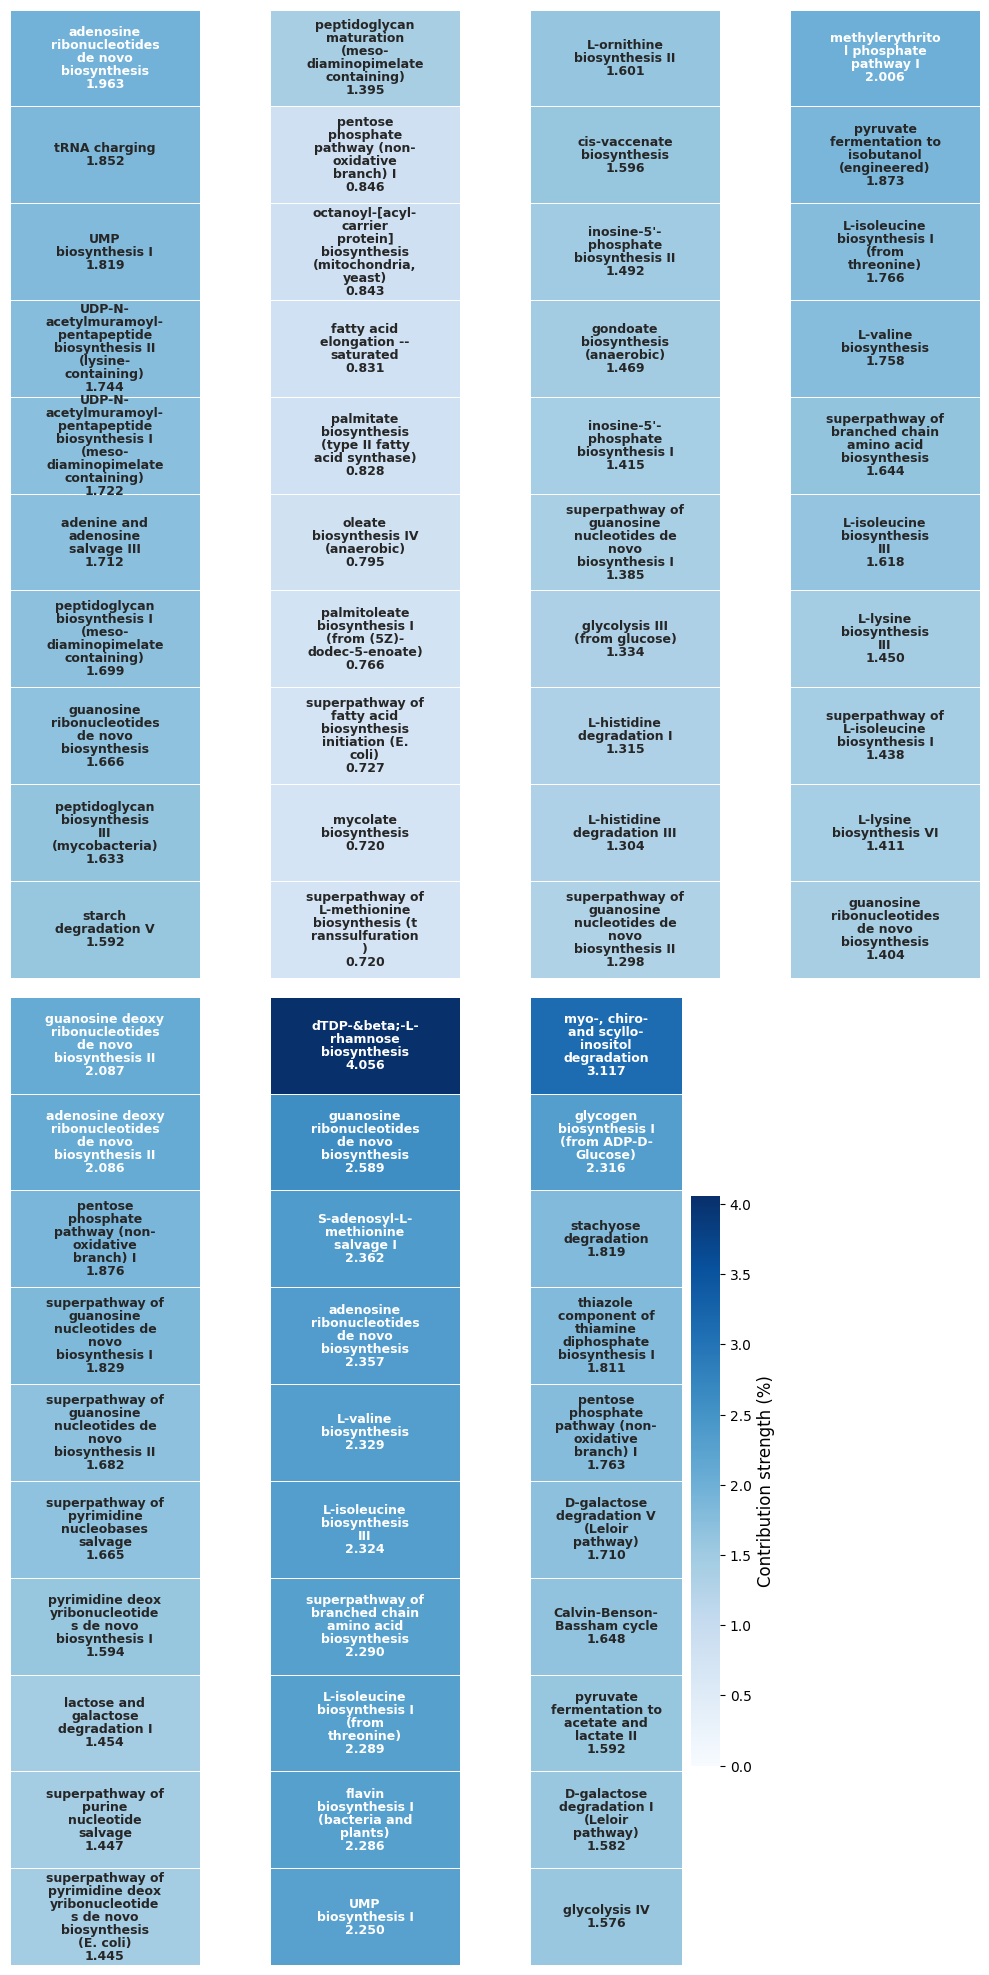

In [50]:
top_functions = show_top_pathways(df=W_norm_col_annot, n_top_features=10, metacyc_group='pathway')

### Distribution of metabolic pathways across functional ESs

In [54]:
# Superclass2 to highlight (i'm using most dominant superclasses from previous function)
s2_list = []

for v in top_functions_superclass2.values():
    s2 = v.index
    s2 = [s.split('_')[-1] for s in s2]
    s2_list.extend(s2)

# Remove nan
s2_list = [s for s in s2_list if s != 'nan']
s2_list = sorted(list(set(s2_list)))

# W to plot
W = W_norm_col_annot.copy()
W = W.reset_index().sort_values(['Superclass2', 'Superclass1']).set_index('pathway')
W = W.drop('index', axis=1)

# Colors for selected Superclass2
colors = sns.color_palette("tab20b", len(s2_list))
superclass2_colors = {superclass2: colors[i] for i, superclass2 in enumerate(s2_list)}
default_color = 'gray'

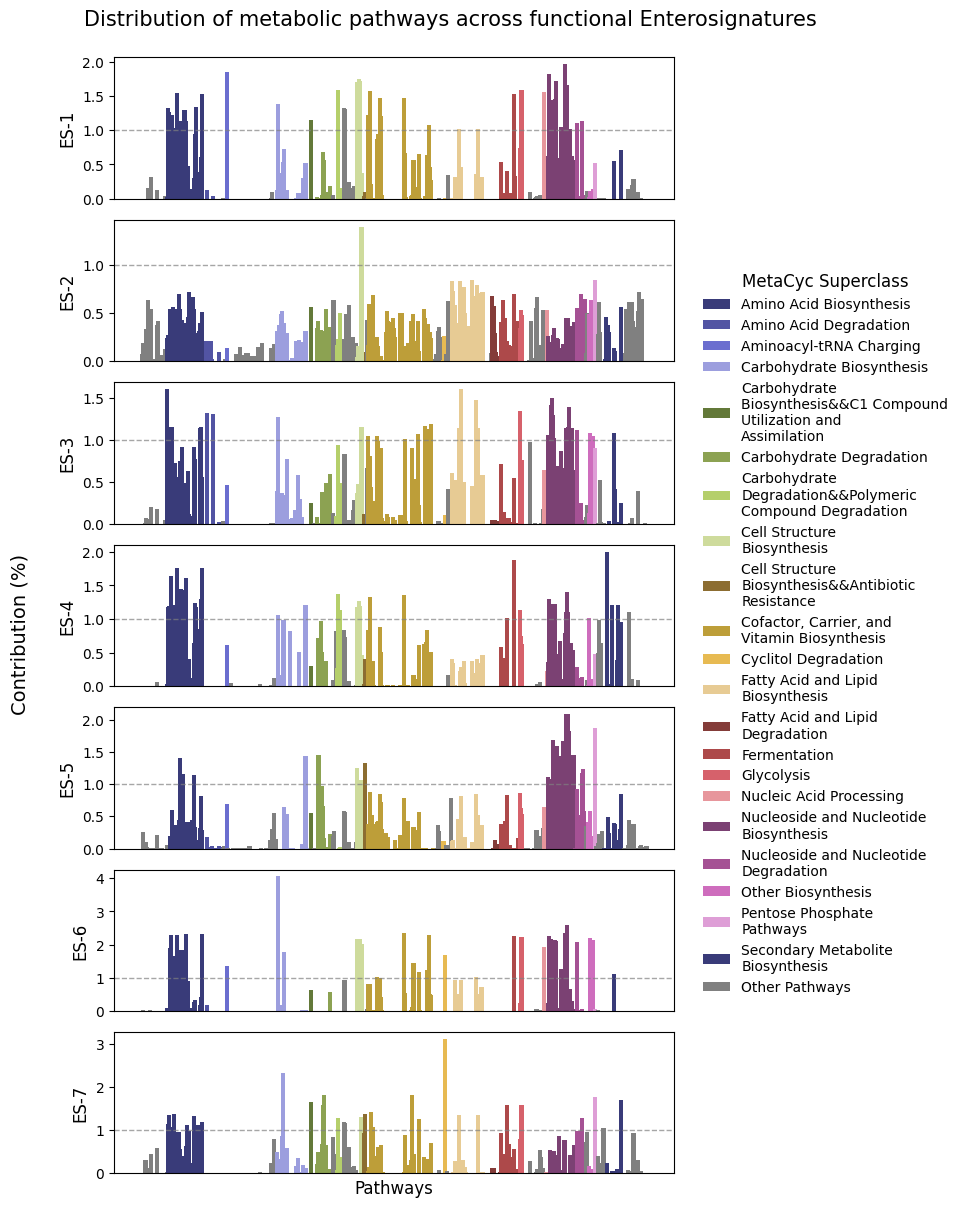

In [57]:
# PLOT
fig, axes = plt.subplots(k, 1, figsize=(8, 12))

for i in range(k):
    group = i + 1
    contributions = W[group]
    superclasses2 = W['Superclass2']

    # Assign colors based on Superclass2
    bar_colors = [superclass2_colors.get(superclass2, default_color) for superclass2 in superclasses2]

    x = np.arange(len(contributions))

    # Bars
    axes[i].bar(x,
                contributions.values,
                color=bar_colors,
                width=5)

    # 1% line
    axes[i].axhline(y=1,
                    color='gray',
                    linestyle='--',
                    linewidth=1,
                    alpha=0.7
                    )

    axes[i].set_xticks([])
    axes[i].set_ylabel(f'ES-{group}', fontsize=12)

# 'Pathways' on bottom
if i == k - 1:
    axes[i].set_xlabel('Pathways', fontsize=12)
    axes[i].set_xticks([])
else:
    axes[i].set_xticks([])

# Y label
fig.supylabel('Contribution (%)', fontsize=14, x=-0.05)

# Legend
legend_labels = {s2: "\n".join(textwrap.wrap(s2, width=25)) for s2 in s2_list} # wrap

legend_handles = [Patch(facecolor=superclass2_colors[s2],
                        edgecolor='none',
                        label=legend_labels[s2]) for s2 in s2_list]

# Other pathways - gray
legend_handles.append(Patch(facecolor='gray',
                            edgecolor='none',
                            label='Other Pathways'))

fig.legend(handles=legend_handles,
    title='MetaCyc Superclass',
    loc='center left',
    bbox_to_anchor=(0.8, 0.5),
    frameon=False,
    fontsize=10,
    title_fontsize=12)

plt.subplots_adjust(
    hspace=0.15,
    top=0.98,
    bottom=0.05,
    left=0.08,
    right=0.78)

fig.suptitle('Distribution of metabolic pathways across functional Enterosignatures', fontsize=15, y=1.02)
#plt.savefig('../images/FEsditr.png', dpi=300, bbox_inches='tight')
plt.show()